<a href="https://colab.research.google.com/github/teju917/Machine_learning_lab2/blob/main/kmeansclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wholesale+customers.zip to wholesale+customers.zip
ORIGINAL DATASET
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

DATASET INFORMATION
Rows: 440
Columns: 8

COLUMNS
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

MISSING VALUES
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


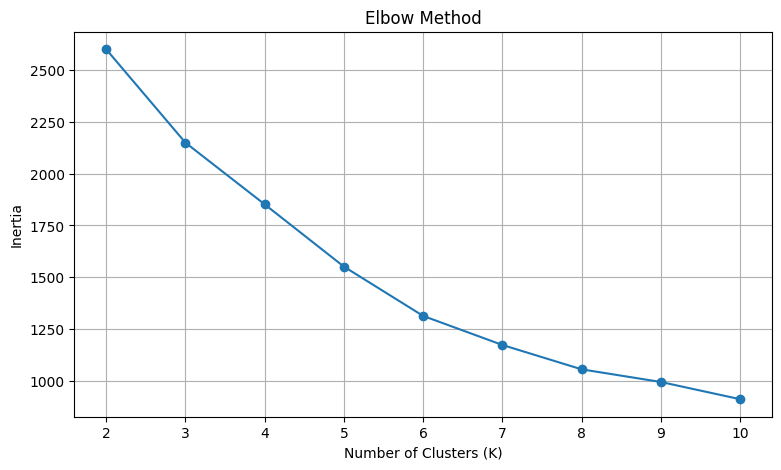


K-MEANS CLUSTERING RESULTS
Number of clusters: 5
Silhouette Score: 0.3529

CLUSTER COUNTS
Cluster
0      6
1    126
2     91
3    207
4     10
Name: count, dtype: int64

CLUSTERED DATASET
    Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0         2       3  12669   9656     7561     214              2674   
1         2       3   7057   9810     9568    1762              3293   
2         2       3   6353   8808     7684    2405              3516   
3         1       3  13265   1196     4221    6404               507   
4         2       3  22615   5410     7198    3915              1777   
5         2       3   9413   8259     5126     666              1795   
6         2       3  12126   3199     6975     480              3140   
7         2       3   7579   4956     9426    1669              3321   
8         1       3   5963   3648     6192     425              1716   
9         2       3   6006  11093    18881    1159              7425   
10        2       3

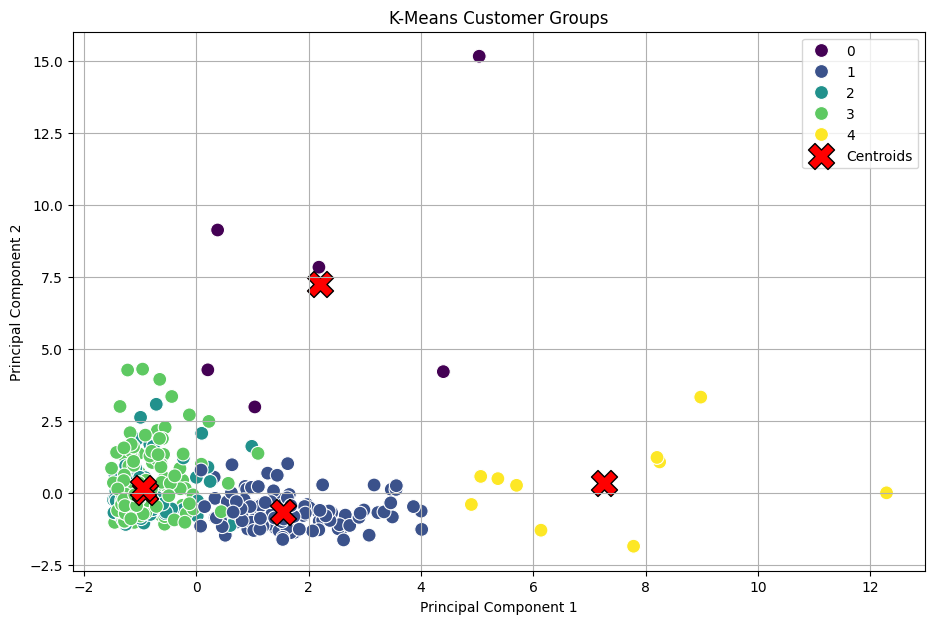

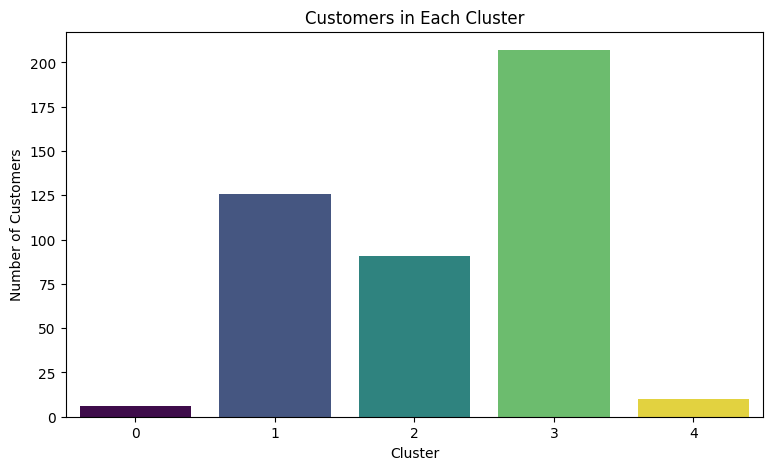

In [4]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("ORIGINAL DATASET")
print(df.head())

print("\nDATASET INFORMATION")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCOLUMNS")
print(df.columns.tolist())

print("\nMISSING VALUES")
print(df.isnull().sum())

X = df.select_dtypes(include="number")

X = X.dropna()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(2, 11))
plt.grid()

plt.show()

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df_clustered = df.loc[X.index].copy()

df_clustered["Cluster"] = clusters

silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("\n" + "=" * 60)
print("K-MEANS CLUSTERING RESULTS")
print("=" * 60)

print("Number of clusters:", k)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print("\nCLUSTER COUNTS")

print(
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nCLUSTERED DATASET")

print(
    df_clustered.head(15)
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

centers_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustered,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=350,
    color="red",
    edgecolor="black",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Customer Groups"
)

plt.legend()

plt.grid()

plt.show()

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clustered,
    x="Cluster",
    hue="Cluster",
    palette="viridis",
    legend=False
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.title(
    "Customers in Each Cluster"
)

plt.show()